In [1]:
import os
import sys
from datetime import datetime
import itertools

from importlib import reload
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')
os.chdir(current_dir)
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)
import plotting
import pinns
import infinite
reload(plotting)
reload(pinns)
reload(infinite)
import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
import torch
import torch.nn as nn
import torch.optim as optim
from pinns import  MLP, init_weights, CoefficientNet, pde_loss_inf, observation_loss_u, observation_loss_k, train_dual_network, build_models, set_seed,run_experiment_inf,build_models_KAN
from pinns import build_models
from infinite import analytical_solution_inf, coefficient_inf, source_term_inf, generate_dataset_inf, evaluate_model_inf
torch.set_default_dtype(torch.float32)
from plotting import plot_histories_comparison

set_seed(1)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

/home/orincon/miniconda3/envs/PIKAN-unbounded-domains-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<>:162: SyntaxWarning: invalid escape sequence '\p'
<>:170: SyntaxWarning: invalid escape sequence '\p'
<>:162: SyntaxWarning: invalid escape sequence '\p'
<>:170: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_13689/1038906967.py:162: SyntaxWarning: invalid escape sequence '\p'
  ax4.set_ylabel("$\partial u / \partial x$ (ms)", fontsize=7, color=palette["text_muted"])
/tmp/ipykernel_13689/1038906967.py:170: SyntaxWarning: invalid escape sequence '\p'
  ax5.set_ylabel("$\partial^2 u / \partial x^2$ (ms)", fontsize=7, color=palette["text_muted"])


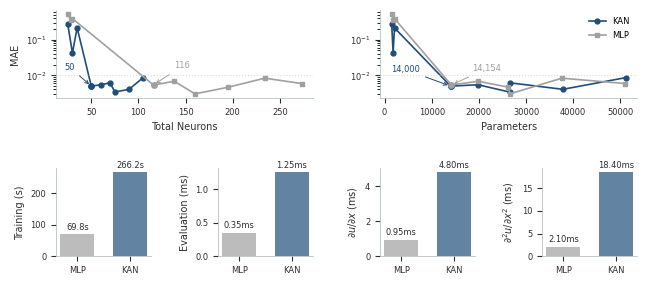

Figure successfully saved to figures/tradeoff.pdf


In [69]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# Custom Aesthetic Palette
# =========================================================
palette = {
    "kan": "#1f4e79ff",          # Deep professional blue for KAN
    "mlp": "#A0A0A0FF",          # Neutral professional gray for MLP
    "text_muted": "#2e2e2e",   # Muted color for labels/ticks
    "spine": "#aab7b8",        # Subtle color for axis spines
    "target_line": "#cecece"   # Accent for the threshold
}

# =========================================================
# Load Data & Clean Headers
# =========================================================
results_dir = "results_accuracy_efficiency_4"
csv_path = os.path.join(results_dir, "summary_metrics.csv")

try:
    df = pd.read_csv(csv_path)
except FileNotFoundError:
    print(f"File {csv_path} not found. Please ensure the path is correct.")

df.columns = df.columns.str.strip()

# =========================================================
# Feature Engineering (Neurons & Global Mean Error)
# =========================================================
df['neurons'] = df['hidden_layers'] * df['hidden_units']
df['err_global_mean'] = df[['err_u_global', 'err_k_global']].mean(axis=1)

# =========================================================
# Plotting Layout (constrained_layout=False para permitir subplots_adjust)
# =========================================================
fig = plt.figure(figsize=(7.5, 3.2), constrained_layout=False)
gs = fig.add_gridspec(2, 4)

# Top row: Two plots spanning 2 columns each
ax0 = fig.add_subplot(gs[0, 0:2])  # Left: Neurons
ax1 = fig.add_subplot(gs[0, 2:4])  # Right: Parameters

# Bottom row: 4 distinct panels for efficiency metrics
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[1, 2])
ax5 = fig.add_subplot(gs[1, 3])

# Control manual del espaciado (puedes ajustar wspace y hspace aquí)
plt.subplots_adjust(wspace=0.7, hspace=0.8)

df_kan = df[df["model_type"] == "KAN"]
df_mlp = df[df["model_type"] == "MLP"]

target_error = 1e-2  # Target error threshold
col_name = "err_global_mean"

# ---------------------------------------------------------
# Helper Function for Top Panels (Neurons & Parameters)
# ---------------------------------------------------------
def plot_accuracy_tradeoff(ax, x_col, x_label, show_ylabel=True, show_legend=True):
    kan_sorted = df_kan.sort_values(x_col)
    mlp_sorted = df_mlp.sort_values(x_col)

    ax.plot(kan_sorted[x_col], kan_sorted[col_name], marker='o', linestyle='-', color=palette["kan"], lw=1.2, ms=3.5, label="KAN")
    ax.plot(mlp_sorted[x_col], mlp_sorted[col_name], marker='s', linestyle='-', color=palette["mlp"], lw=1.2, ms=3.5, label="MLP")

    ax.axhline(target_error, color=palette["target_line"], linestyle=':', linewidth=0.8, alpha=0.7)

    for df_sub, color, model_name in [(kan_sorted, palette["kan"], "KAN"), 
                                      (mlp_sorted, palette["mlp"], "MLP")]:
        if not df_sub.empty:
            achieved = df_sub[df_sub[col_name] <= target_error]
            if not achieved.empty:
                best_row = achieved.iloc[0]
            else:
                best_idx = (df_sub[col_name] - target_error).abs().idxmin()
                best_row = df_sub.loc[best_idx]
                
            x_val = best_row[x_col]
            y_val = best_row[col_name]
            
            ax.scatter(x_val, y_val, color=color, s=15, zorder=5)
            
            if x_col == "neurons":
                if model_name == "KAN":
                    xytext_offset = (-12, 12)
                    ha_val = 'right'
                else:
                    xytext_offset = (15, 12)
                    ha_val = 'left'
            else:
                if model_name == "KAN":
                    xytext_offset = (-22, 10)
                    ha_val = 'right'
                else:
                    xytext_offset = (15, 10)
                    ha_val = 'left'
            
            ax.annotate(
                f"{int(x_val):,}",
                xy=(x_val, y_val),
                xytext=xytext_offset,
                textcoords="offset points",
                ha=ha_val,
                fontsize=6,
                color=color,
                arrowprops=dict(
                    arrowstyle="->",
                    color=color,
                    lw=0.7,
                    connectionstyle="arc3,rad=0"
                )
            )

    ax.set_yscale('log')
    ax.set_xlabel(x_label, fontsize=7, color=palette["text_muted"])
    if show_ylabel:
        ax.set_ylabel("MAE", fontsize=7, color=palette["text_muted"])
    
    if show_legend:
        ax.legend(frameon=False, fontsize=6, loc="upper right")

# ---------------------------------------------------------
# Top Row: Render Neurons (ax0) and Parameters (ax1)
# ---------------------------------------------------------
plot_accuracy_tradeoff(ax0, x_col="neurons", x_label="Total Neurons", show_ylabel=True, show_legend=False)
plot_accuracy_tradeoff(ax1, x_col="parameters", x_label="Parameters", show_ylabel=False, show_legend=True)

# ---------------------------------------------------------
# Panels: Efficiency & Autograd Barplots (Bottom Row) - MLP on Left
# ---------------------------------------------------------
models = ['MLP', 'KAN']
bar_colors = [palette["mlp"], palette["kan"]]

# Training Runtime Barplot (ax2)
time_kan = df_kan["compute_time_sec"].mean()
time_mlp = df_mlp["compute_time_sec"].mean()
bars1 = ax2.bar(models, [time_mlp, time_kan], color=bar_colors, width=0.65, alpha=0.7)
for bar in bars1:
    ax2.annotate(f'{bar.get_height():.1f}s', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 xytext=(0, 2), textcoords="offset points", ha='center', va='bottom', fontsize=6, color=palette["text_muted"])
ax2.set_ylabel("Training (s)", fontsize=7, color=palette["text_muted"])

# Forward Evaluation Time Barplot (ax3)
eval_times = [0.35, 1.25]
bars2 = ax3.bar(models, eval_times, color=bar_colors, width=0.65, alpha=0.7)
for bar in bars2:
    ax3.annotate(f'{bar.get_height():.2f}ms', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 xytext=(0, 2), textcoords="offset points", ha='center', va='bottom', fontsize=6, color=palette["text_muted"])
ax3.set_ylabel("Evaluation (ms)", fontsize=7, color=palette["text_muted"])

# 1st Derivative Time Barplot (ax4)
d1_times = [0.95, 4.80]
bars3 = ax4.bar(models, d1_times, color=bar_colors, width=0.65, alpha=0.7)
for bar in bars3:
    ax4.annotate(f'{bar.get_height():.2f}ms', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 xytext=(0, 2), textcoords="offset points", ha='center', va='bottom', fontsize=6, color=palette["text_muted"])
ax4.set_ylabel("$\partial u / \partial x$ (ms)", fontsize=7, color=palette["text_muted"])

# 2nd Derivative Time Barplot (ax5)
d2_times = [2.10, 18.40]
bars4 = ax5.bar(models, d2_times, color=bar_colors, width=0.65, alpha=0.7)
for bar in bars4:
    ax5.annotate(f'{bar.get_height():.2f}ms', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 xytext=(0, 2), textcoords="offset points", ha='center', va='bottom', fontsize=6, color=palette["text_muted"])
ax5.set_ylabel("$\partial^2 u / \partial x^2$ (ms)", fontsize=7, color=palette["text_muted"])

# =========================================================
# Global Styling & Spacing Adjustments
# =========================================================
all_axes = [ax0, ax1, ax2, ax3, ax4, ax5]
for ax in all_axes:
    ax.tick_params(axis="both", labelsize=6, colors=palette["text_muted"])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for spine_name in ['bottom', 'left']:
        ax.spines[spine_name].set_color(palette["spine"])
        ax.spines[spine_name].set_linewidth(0.5)

os.makedirs("figures", exist_ok=True)
fig_path = "figures/tradeoff.pdf"
plt.savefig(fig_path, bbox_inches='tight', dpi=300)
plt.show()

print(f"Figure successfully saved to {fig_path}")